### Preparing the dataset

In [1]:
# We will prepare the dataset to fine-tune the gpt-2
# pretrained model for text classification

import urllib.request
import zipfile
import os
from pathlib import Path

url = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
    url, zip_path, extracted_path, data_file_path,):
  if data_file_path.exists():
    print(f"{data_file_path} already exists. Skipping download and extraction.")
    return

  with urllib.request.urlopen(url) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

  original_file_path = Path(extracted_path) / 'SMSSpamCollection'
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and saved as {data_file_path}")

In [2]:
# Let's now use the utility function to download and extract the dataset
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [3]:
# We can now load the dataset into a pandas dataframe
import pandas as pd

df = pd.read_csv(
    data_file_path, sep='\t', header=None, names=['Label', 'Text']
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
# Let's examine the class label distribution
print(df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
# For simplicity, we will undersample the majority class to create a
# balanced dataset
def create_balanced_dataset(df):
  num_spam = df[df['Label'] == 'spam'].shape[0]
  ham_subset = df[df['Label'] == 'ham'].sample(
      num_spam, random_state=123,
  )
  balanced_df = pd.concat([
      ham_subset, df[df['Label'] == 'spam']
  ])

  return balanced_df

In [6]:
balanced_df = create_balanced_dataset(df)
print(balanced_df['Label'].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [7]:
# Convert the class labels 'ham' and 'spam' into integers 0 and 1 respectively
balanced_df['Label'] = balanced_df['Label'].map({'ham': 0, 'spam': 1})

In [8]:
# Next we create a function to split the dataset into train, validation and test
# subsets
def random_split(df, train_frac, validation_frac):
  df = df.sample(
      frac=1, random_state=123,
  ).reset_index(drop=True)
  train_end = int(len(df )* train_frac)
  validation_end = train_end + int(len(df) * validation_frac)

  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]

  return train_df, validation_df, test_df

In [9]:
train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1)

In [10]:
# Let's save the dataset as a CSV file so we can reuse it
train_df.to_csv('train.csv', index=None)
validation_df.to_csv('validation.csv', index=None)
test_df.to_csv('test.csv', index=None)

### Creating data loaders
Since now we are dealing with different lengths for the text of each sample, we
need to pad the encoded token sequences to match the length of the longest token sequence sample. To do this, we will use the `<|endoftext|>` token, which
if you remind, has a token ID of 50256.

In [11]:
# Token ID of <|endoftext|>
import tiktoken

tokenizer = tiktoken.get_encoding('gpt2')
print(tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'}))

[50256]


In [12]:
# First we need to define a PyTorch Dataset class to define how the dataset is
# loaded and processed before we can instantiate the dataloader
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256,):
    self.data = pd.read_csv(csv_file)

    self.encoded_texts = [tokenizer.encode(text) for text in self.data['Text']]

    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length

    self.encoded_texts = [
        encoded_text[:self.max_length] for encoded_text in self.encoded_texts
    ]

    self.encoded_texts = [
        encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
        for encoded_text in self.encoded_texts
    ]

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]['Label']
    return (
        torch.tensor(encoded, dtype=torch.long),
        torch.tensor(label, dtype=torch.long),
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

In [13]:
train_dataset = SpamDataset(
    csv_file='train.csv',
    max_length=None,
    tokenizer=tokenizer)
print(train_dataset.max_length)

120


In [14]:
# Next, we pad the validation and test sets to match the length of the longest training sequence.
# Importantly, any validation and test set samples exceeding the length of the longest training example
# are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier.
# This truncation is optional; you can set max_length=None for both validation and test sets, provided
# there are no sequences exceeding 1,024 tokens

val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [15]:
# We can now create the data loaders to load the train, validation and test
# datasets into batches of 8 samples each
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [16]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [17]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### Initializing a model with pretrained weights

In [18]:
CHOOSE_MODEL = 'gpt2-small (124M)'
INPUT_PROMPT = 'Every effort moves you'
BASE_CONFIG = {
    'vocab_size': 50257,
    'context_length': 1024,
    'drop_rate': 0.0,
    'qkv_bias': True,
}

model_configs = {
    'gpt2-small (124M)': {'emb_dim': 768, 'n_layers': 12, 'n_heads': 12,},
    'gpt2-medium (355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads': 16,},
    'gpt2-large (774M)': {'emb_dim': 1280, 'n_layers': 36, 'n_heads': 20,},
    'gpt2-xl (1558M)': {'emb_dim': 1600, 'n_layers': 48, 'n_heads': 25,},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [19]:
# Download utility functions and GPT class we implemented previously from
# Raschka's GitHub.
import urllib.request
from pathlib import Path
urls = [
    'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch06/01_main-chapter-code/gpt_download.py',
    'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch06/01_main-chapter-code/previous_chapters.py',
]
file_paths = [url.split('/')[-1] for url in urls]

for url, file_path in zip(urls, file_paths):
  with urllib.request.urlopen(url) as response:
    with open(file_path, 'wb') as fp:
      fp.write(response.read())


In [20]:
# Now we can load pretrained weights on our gpt2 instance
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(' ')[-1].lstrip('(').rstrip(')')
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir='gpt2'
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 218kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 635kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 269kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:58<00:00, 2.79MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 12.8MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 383kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 449kiB/s]


In [21]:
# Now we use the text generation utility function we already implemented
# to ensure the model generate coherent text
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text)

text_1 = 'Every effort moves you'
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG['context_length'],
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [22]:
# Before fine-tuning the model as a classifier, let's see if the
# model is capable of classifying text samples if given the correct
# instructions

text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG['context_length'],
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


### Adding a classification head

In [23]:
# We will replace the last output layer that maps hidden token representation
# to the vocabulary size of the model with a simpler layers that maps the hidden
# representations to our two taget classes, i.e. 'ham' and 'spam'
# Let's see the current architecture of the gpt model
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [24]:
# Since we have a pretrained model, to both use resources efficiently and
# also due to how neural network based language models work (i.e. first layers
# catch general language patterns while deeper layers deal with more nuanced
# representation and specific tasks), it is a standard procedure to only train
# the replaced layer while freezing the weights of the rest of the network.
# In PyTorch, we have to do the following to freeze weights during training
for param in model.parameters():
  param.requires_grad = False

In [25]:
# Now we can replace the output layer with the new simpler layer for the
# classification task
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG['emb_dim'],
    out_features=num_classes,
)

In [26]:
# Technically, only training the last substituted layer is suffiecient,
# but training additional layers can improve performances (at the cost of
# increased training time and cost). Therefore, in addition with the final
# output layer, we will also train the last transformer block and the layer
# normalization connecting the last transformer block with the final output layer
for param in model.trf_blocks[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True

In [27]:
# Even if we modified the model, we can still use the model normally
inputs = tokenizer.encode('Do you have time')
inputs = torch.tensor(inputs).unsqueeze(0)
print('Inputs:', inputs)
print('Inputs dimensions:', inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [28]:
# We can pass tokens into the model as usual
with torch.no_grad():
  outputs = model(inputs)
print('Outputs:', outputs)
print('Outputs dimensions:', outputs.shape)

Outputs: tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [29]:
# We are interested in fine-tuning the model with respect to the
# last output token (due to the causal attention mask, the last token is the
# only one that embeds information for the whole input sequence).
# We can extract it with the following syntax
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


### Calculating the classification loss and accuracy

In [30]:
# We can compute the model prediction as we did for the text generation task
# with the only difference that now we only have 2 embedding dimensions instead
# of vocab_size
print("Last output token:", outputs[:, -1, :])
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Last output token: tensor([[-3.5983,  3.9902]])
Class label: 1


In [31]:
# We can also directly apply the argmax to the logits as the highest logit
# always correspond to the highest output probability
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [32]:
# We can apply this to all the examples of the dataset and calculate the
# proportion of correct predictions

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
  model.eval();
  correct_predictions, num_examples = 0, 0

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      input_batch = input_batch.to(device)
      target_batch = target_batch.to(device)

      with torch.no_grad():
        logits = model(input_batch)[:, -1, :]
      predicted_labels = torch.argmax(logits, dim=-1)

      num_examples += predicted_labels.shape[0]
      correct_predictions += (
          (predicted_labels == target_batch).sum().item()
      )
    else:
      break

  return correct_predictions / num_examples

In [33]:
# Let's use this utility function to estimate the accuracy across
# different dataloaders using only 10 batches for efficiency

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [34]:
# We can use the same calc_loss_batch function we used previously
# with the only difference that we optimize the loss only for the
# last token embedding instead of all of them
def calc_loss_batch(input_batch, target_batch, model, device):
  model.eval();
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)[:, -1, :]
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss

In [35]:
# To calculate the loss for the whole loader, we define the
# following function
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break

  return total_loss / num_batches

In [36]:
# Similarly as we did with the accuracy, we can calculate the loss for
# each dataset
with torch.no_grad():
  train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=5,
  )
  val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=5,
  )
  test_loss = calc_loss_loader(
      test_loader, model, device, num_batches=5,
  )
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


### Fine-Tuning the model on supervised data

In [37]:
# This function is almost exacly the same as the one used for pretraining
# the model, with the exception of the fact that we are now tracking
# examples seen instead of tokens and also we are calculating classification
# accuracy instead of generating sample text for visual inspection

def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1


            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )


        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [38]:
# The evaluate_model function is identical to the one we used for
# pretraining the model

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )
  model.train()
  return train_loss, val_loss

In [39]:
# We can finally fine-tune the model!
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
  train_classifier_simple(
      model, train_loader, val_loader, optimizer, device,
      num_epochs=num_epochs, eval_freq=50,
      eval_iter=5
  )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 1.22 mi

In [40]:
# Plot the loss function for the training and validation sets
import matplotlib.pyplot as plt

def plot_values(
    epoch_seen, examples_seen, train_values, val_values,
    label='loss'):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epoch_seen, train_values, label=f"Training {label}")
  ax1.plot(epoch_seen, val_values,
  linestyle='-.', label=f"Validation {label}")
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  ax2 = ax1.twiny()
  ax2.plot(examples_seen, train_values, alpha=0)
  ax2.set_xlabel("Example seen")

  fig.tight_layout()
  plt.savefig(f"{label}-plot.pdf")
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

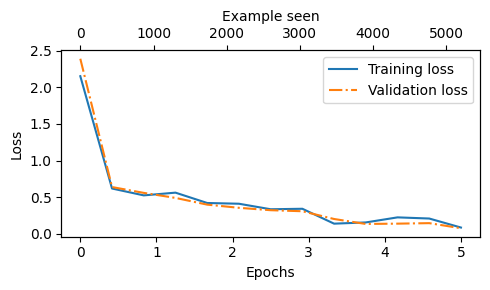

In [41]:
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

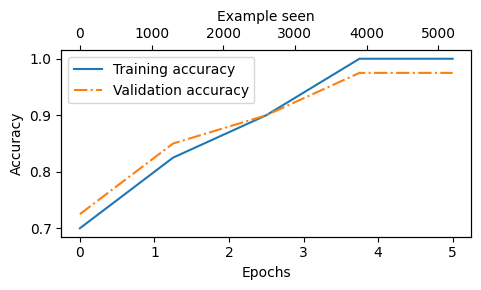

In [42]:
# Using the same plot_values function, let's plot the
# classification accuracies
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs,
            label='accuracy'
            )

In [43]:
# Calculate the performance metrics across whole training, validation
# and test datasets

train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


### Using the LLM as a spam classifier

In [44]:
# Finally, we can use the fine-tuned model to
# classify new texts

def classify_review(
    text, model, tokenizer, device, max_length=None,
    pad_token_id=50256):
  model.eval()

  input_ids = tokenizer.encode(text)
  supported_context_length = model.pos_emb.weight.shape[0]

  input_ids = input_ids[:min(max_length, supported_context_length)]

  input_ids += [pad_token_id] * (max_length - len(input_ids))

  input_ids = torch.tensor(
      input_ids, device=device
  ).unsqueeze(0)

  with torch.no_grad():
    logits = model(input_ids)[:, -1, :]
  predicted_label = torch.argmax(logits, dim=-1).item()

  return 'spam' if predicted_label == 1 else 'not spam'

In [45]:
# Let's try the classifying function on some example text
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [46]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [47]:
# Save the model
torch.save(model.state_dict(), "review_classifier.pth")

In [48]:
# Load the model
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>